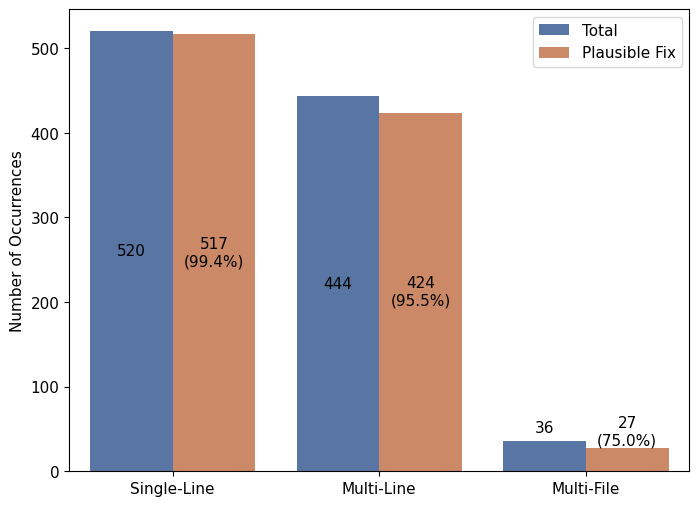

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

single_line_absolute_number = 520
single_line_plausible_fix = 517

multi_line_absolute_number = 444
multi_line_plausible_fix = 424

multi_file_absolute_number = 36
multi_file_plausible_fix = 27

# Calculate percentages
single_line_percentage = (single_line_plausible_fix / single_line_absolute_number) * 100
multi_line_percentage = (multi_line_plausible_fix / multi_line_absolute_number) * 100
multi_file_percentage = (multi_file_plausible_fix / multi_file_absolute_number) * 100

# Grouped bar plot
data = {
    'Type': ['Single-Line', 'Multi-Line', 'Multi-File'],
    'Total': [single_line_absolute_number, multi_line_absolute_number, multi_file_absolute_number],
    'Plausible Fix': [single_line_plausible_fix, multi_line_plausible_fix, multi_file_plausible_fix]
}

df = pd.DataFrame(data)
percentages = [single_line_percentage, multi_line_percentage, multi_file_percentage]

# Use seaborn's palette to get the same colors as in the tool call plots
palette = ["#4c72b0", "#dd8456"]

plt.figure(figsize=(8, 6))

plt.rcParams["font.size"] = 11
# Use TruType fonts instead of Type 3
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

# Use seaborn barplot like in the tool call plots
ax = sns.barplot(x="Tool", y="value", hue="variable",
                 data=pd.melt(df, id_vars=["Type"], value_vars=["Total", "Plausible Fix"], 
                             var_name="variable", value_name="value").rename(columns={"Type": "Tool"}),
                 palette=palette)

# Add the numbers inside the bars
bars = ax.patches
for i, bar in enumerate(bars[:6]):  # Only annotate the first 6 bars
    height = bar.get_height()
    if i >= 3:  # Plausible Fix bars (second set)
        percentage_idx = i - 3
        label = f'{int(height)}\n({percentages[percentage_idx]:.1f}%)'
    else:  # Total bars (first set)
        label = f'{int(height)}'
    offset = 0
    if i == 2 or i == 5:  # For the last bar, adjust the position to avoid overlap
        offset = 33
    
    ax.annotate(label,
                xy=(bar.get_x() + bar.get_width() / 2, height / 2 + offset),
                ha='center', va='center')

ax.set_ylabel('Number of Occurrences')
ax.set_xlabel('')
plt.legend()
plt.savefig("../evaluation_results/plots/fix_complexity_bar_plot.png", dpi=300)

plt.show()